In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv("ds_salaries.csv")

In [2]:
# 2. 직무 간소화 함수 정의
def simplify_job_title(title):
    title = title.lower()
    if "scientist" in title:
        return "scientist"
    elif "engineer" in title:
        return "engineer"
    elif "analyst" in title:
        return "analyst"
    elif "manager" in title or "lead" in title:
        return "manager"
    elif "architect" in title:
        return "architect"
    elif "developer" in title:
        return "developer"
    else:
        return "other"

df["job_group"] = df["job_title"].apply(simplify_job_title)

# 3. 숫자형 변수로 매핑
experience_map = {"EN": 0, "MI": 1, "SE": 2, "EX": 3}
size_map = {"S": 0, "M": 1, "L": 2}
df["experience_level_num"] = df["experience_level"].map(experience_map)
df["company_size_num"] = df["company_size"].map(size_map)

# 4. 평균 기준으로 이진 타겟 생성
mean_salary = df["salary_in_usd"].mean()
df["salary_binary"] = df["salary_in_usd"].apply(lambda x: "High" if x >= mean_salary else "Low")

# 5. 피처와 타겟 설정
features = ['work_year', 'experience_level_num', 'employment_type', 'job_group',
            'employee_residence', 'remote_ratio', 'company_location', 'company_size_num']
target = 'salary_binary'

X = df[features]
y = df[target]

# 6. train/test 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. 범주형 변수 전처리
categorical_features = ['employment_type', 'job_group', 'employee_residence', 'company_location']
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

# 8. 모델 파이프라인 구성 및 학습
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])
pipe.fit(X_train, y_train)

# 9. 예측 및 평가
y_pred = pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# 10. 결과 출력
print("✅ 평균 연봉 기준 이진 분류 결과")
print(f"정확도 (Accuracy): {round(acc * 100, 2)}%")
print("\n분류 리포트 (classification_report):\n")
print(report)

NameError: name 'train_test_split' is not defined

In [ ]:
# 결측치 개수 확인
print(df.isnull().sum())

# 결측치가 있다면 제거 또는 채우기
df = df.dropna()  # 간단하게 제거

Unnamed: 0              0
work_year               0
experience_level        0
employment_type         0
job_title               0
salary                  0
salary_currency         0
salary_in_usd           0
employee_residence      0
remote_ratio            0
company_location        0
company_size            0
job_group               0
experience_level_num    0
company_size_num        0
salary_binary           0
dtype: int64


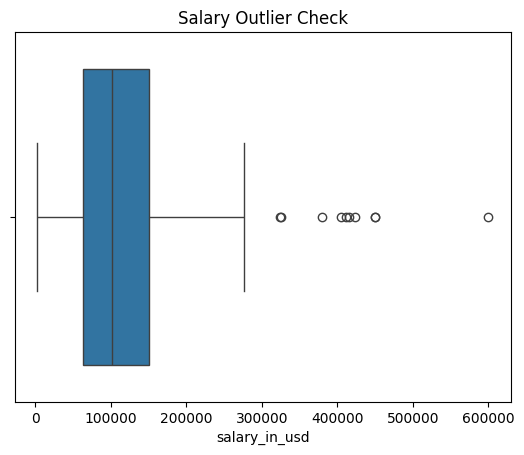

In [ ]:
# 연봉 이상치 분포 확인
sns.boxplot(x=df['salary_in_usd'])
plt.title("Salary Outlier Check")
plt.show()

# 너무 큰 연봉 제거 (예: 600,000 이상은 제거해보기)
df = df[df['salary_in_usd'] < 600000]

In [ ]:
df['log_salary'] = np.log1p(df['salary_in_usd'])

In [ ]:
# 직무 간소화
def simplify_job_title(title):
    title = title.lower()
    if "scientist" in title:
        return "scientist"
    elif "engineer" in title:
        return "engineer"
    elif "analyst" in title:
        return "analyst"
    elif "manager" in title or "lead" in title:
        return "manager"
    elif "architect" in title:
        return "architect"
    elif "developer" in title:
        return "developer"
    else:
        return "other"

df["job_group"] = df["job_title"].apply(simplify_job_title)

# 경력 및 회사 규모 숫자형 매핑
experience_map = {"EN": 0, "MI": 1, "SE": 2, "EX": 3}
size_map = {"S": 0, "M": 1, "L": 2}

df["experience_level_num"] = df["experience_level"].map(experience_map)
df["company_size_num"] = df["company_size"].map(size_map)